<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_13th_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab: uncomment to install missing packages
# !pip install seaborn scikit-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
%matplotlib inline


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mfrye0/bigpicture-company-dataset")

print("Path to dataset files:", path)

100%|██████████| 608M/608M [00:07<00:00, 84.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mfrye0/bigpicture-company-dataset/versions/5


In [4]:
FILE = "companies-2023-q4-sm.csv"   # your file in Colab working dir
assert os.path.exists(FILE), f"File not found: {FILE}. Upload it to Colab first."

data = pd.read_csv(FILE)
print("Rows, Columns:", data.shape)
display(data.head())
display(data.dtypes)
display(data.describe(include="all").T)
print("Missing values per column:")
display(data.isnull().sum().sort_values(ascending=False).head(50))


Rows, Columns: (34680, 10)


,handle,name,website,industry,size,type,founded,city,state,country_code
0,company/&-shayna-solution-partners,& Shayna solution partners,andshayna.com,retail,1-10,Partnership,NaN,NaN,NaN,NaN
1,company/'addinall-management-and-systems','Addinall Management and Systems',NaN,business consulting and services,NaN,NaN,NaN,NaN,NaN,NaN
2,company/'baden-regio'-gemeinden-region-baden-w...,"'Baden Regio', Gemeinden Region Baden-Wettingen",baden-regio.ch,NaN,NaN,NaN,NaN,Wettingen,Aargau,CH
3,company/'friends-with-rice'​-stichting-'vriend...,'Friends With Rice' / Stichting 'Vrienden Met ...,vriendenmetrijst.nl,philanthropic fundraising services,1-10,Nonprofit,2014.0,Lisse,South Holland,NL
4,company/'i-say'-supported-living-services-limited,'I SAY' SUPPORTED LIVING SERVICES LIMITED,NaN,consumer services,NaN,NaN,NaN,Rochester,England,GB


,0
handle,object
name,object
website,object
industry,object
size,object
type,object
founded,float64
city,object
state,object
country_code,object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
handle,34680,34680,c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,34662,34642,A,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
website,27557,26577,facebook.com,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,32088,401,construction,1489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,28742,8,1-10,16896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,23110,8,Privately Held,11564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
founded,17053.0,NaN,NaN,NaN,2006.67859,22.2401,1357.0,2003.0,2013.0,2018.0,2023.0
city,27619,10652,London,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,24803,1609,England,1405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_code,28428,182,US,8644,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:


,0
founded,17627
type,11570
state,9877
website,7123
city,7061
country_code,6252
size,5938
industry,2592
name,18
handle,0


In [5]:
# Standardize column names
data.columns = [c.strip().replace(" ", "_") for c in data.columns]

# Detect types
numeric_cols = list(data.select_dtypes(include=["number"]).columns)
categorical_cols = list(data.select_dtypes(include=["object","category","bool"]).columns)
datetime_cols = [c for c in data.columns if "date" in c.lower() or "time" in c.lower()]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Datetime-like columns:", datetime_cols)

# Parse datetimes if any
for c in datetime_cols:
    try:
        data[c] = pd.to_datetime(data[c])
    except Exception:
        pass

# Remove exact duplicates
data = data.drop_duplicates()

# Coerce numeric-like strings to numeric where appropriate
for c in data.columns:
    if data[c].dtype == "object":
        coerced = pd.to_numeric(data[c].str.replace(",",""), errors="coerce")
        if coerced.notna().sum() / len(coerced) > 0.5:
            data[c] = coerced

# Simple missing-value handling (will be refined later)
print("Missing values after coercion:")
display(data.isnull().sum().sort_values(ascending=False).head(50))

# Quick category comparisons (example: average revenue or a salary-like column if present)
candidate_value_cols = [c for c in numeric_cols if any(k in c.lower() for k in ["revenue","sales","salary","amount","price","value","profit"])]
if candidate_value_cols:
    val = candidate_value_cols[0]
    if "Company" in data.columns:
        display(data.groupby("Company")[val].mean().sort_values(ascending=False).head(20))
    elif "Industry" in data.columns:
        display(data.groupby("Industry")[val].mean().sort_values(ascending=False).head(20))
else:
    print("No obvious revenue/salary numeric column detected; inspect numeric columns above.")


Numeric columns: ['founded']
Categorical columns: ['handle', 'name', 'website', 'industry', 'size', 'type', 'city', 'state', 'country_code']
Datetime-like columns: []
Missing values after coercion:


,0
founded,17627
type,11570
state,9877
website,7123
city,7061
country_code,6252
size,5938
industry,2592
name,18
handle,0


No obvious revenue/salary numeric column detected; inspect numeric columns above.


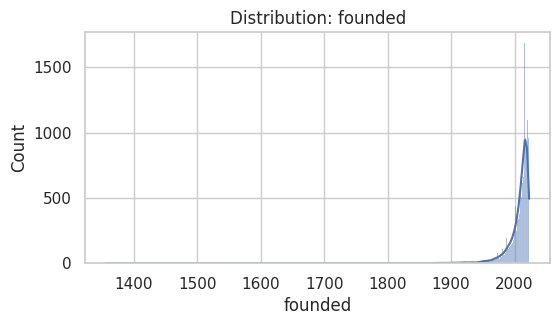

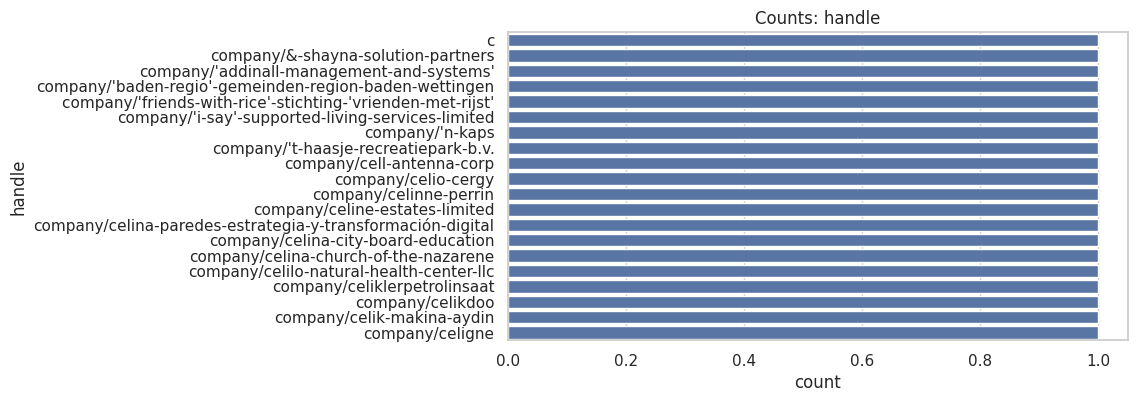

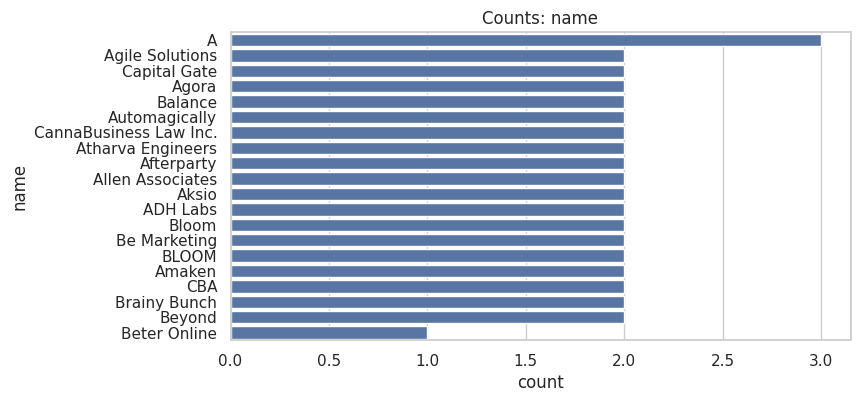

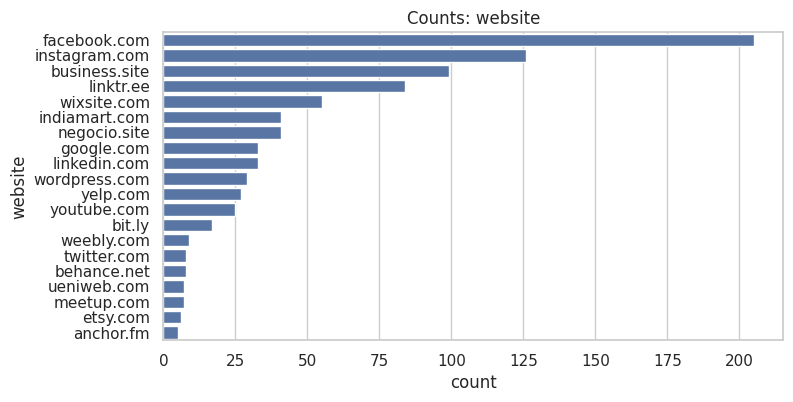

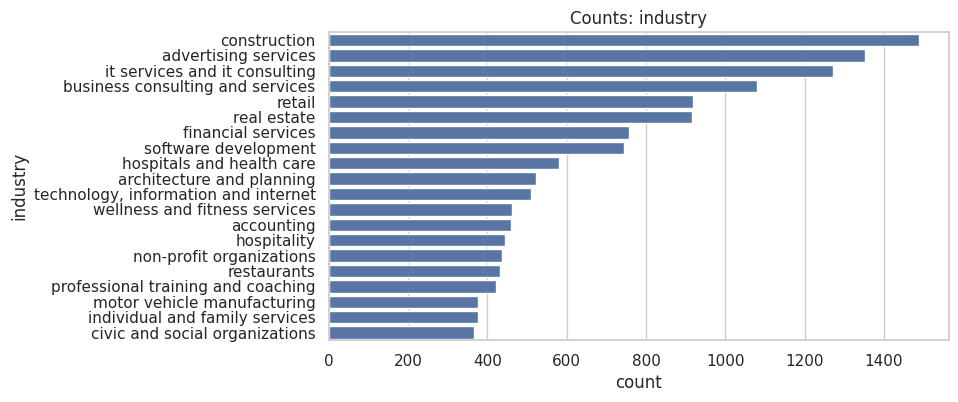

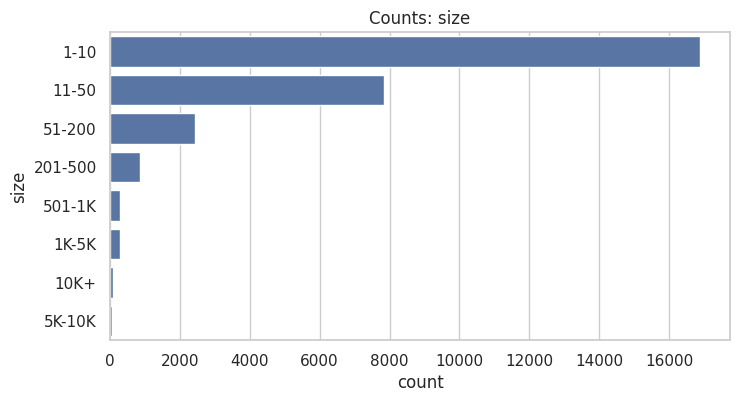

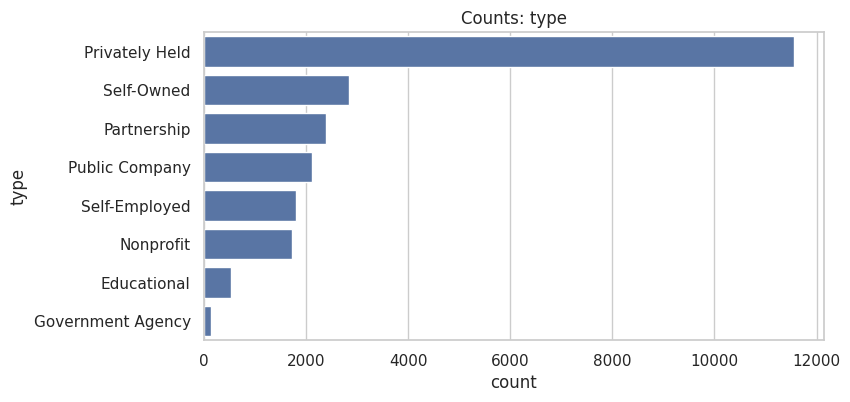

In [6]:
# Univariate EDA for numeric columns
def plot_numeric_distribution(df, cols, max_plots=12):
    cols = cols[:max_plots]
    for c in cols:
        plt.figure(figsize=(6,3))
        sns.histplot(df[c].dropna(), kde=True)
        plt.title(f"Distribution: {c}")
        plt.show()

plot_numeric_distribution(data, numeric_cols, max_plots=12)

# Top categorical counts
for c in categorical_cols[:6]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=c, data=data, order=data[c].value_counts().index[:20])
    plt.title(f"Counts: {c}")
    plt.show()

# Correlation heatmap (numeric)
if len(numeric_cols) > 1:
    plt.figure(figsize=(12,10))
    corr = data[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Numeric correlation matrix")
    plt.show()

# Advanced grouping example: by Industry and Region (if present)
group_cols = [c for c in ["Industry","Region","Country","Sector"] if c in data.columns]
if group_cols and candidate_value_cols:
    pivot = data.groupby(group_cols)[val].mean().unstack(level=-1)
    display(pivot.head(20))


Detected target: None


,handle,name,website,industry,size,type,founded,city,state,country_code
0,company/&-shayna-solution-partners,& Shayna solution partners,andshayna.com,retail,1-10,Partnership,NaN,NaN,NaN,NaN
1,company/'addinall-management-and-systems','Addinall Management and Systems',NaN,business consulting and services,NaN,NaN,NaN,NaN,NaN,NaN
2,company/'baden-regio'-gemeinden-region-baden-w...,"'Baden Regio', Gemeinden Region Baden-Wettingen",baden-regio.ch,NaN,NaN,NaN,NaN,Wettingen,Aargau,CH
3,company/'friends-with-rice'​-stichting-'vriend...,'Friends With Rice' / Stichting 'Vrienden Met ...,vriendenmetrijst.nl,philanthropic fundraising services,1-10,Nonprofit,2014.0,Lisse,South Holland,NL
4,company/'i-say'-supported-living-services-limited,'I SAY' SUPPORTED LIVING SERVICES LIMITED,NaN,consumer services,NaN,NaN,NaN,Rochester,England,GB


No TARGET detected; skipping supervised modeling. Set TARGET variable to run models.


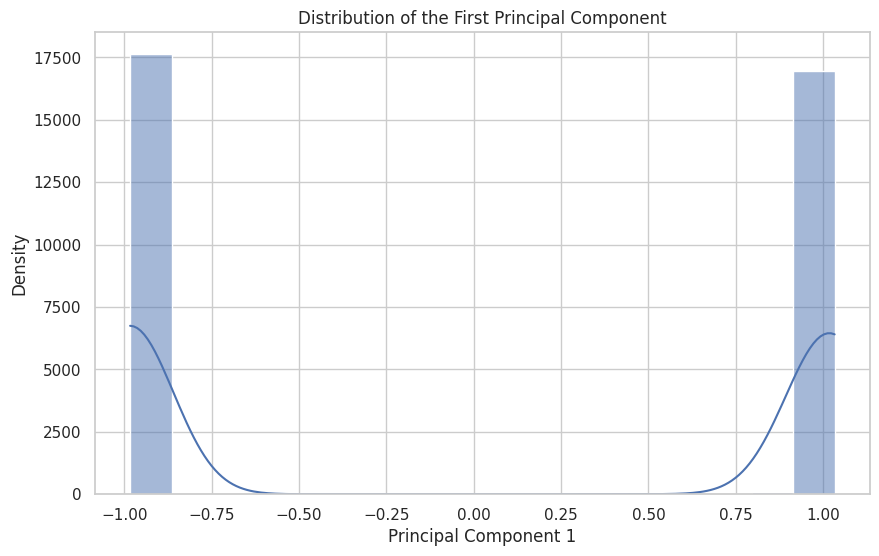

PCA explained variance ratio (first component): 1.0


,0
Cluster,
0,4630
1,17627
2,650
3,11773


Engineered columns sample: []
Saved cleaned dataset to companies_2023_q4_sm_cleaned.csv


In [10]:
 # ---------- Step 10: Task detection ----------
# If you know the target, set TARGET explicitly. Otherwise attempt to infer.
TARGET = None   # e.g., "Churn", "Revenue", "Is_Default"
# Auto-detect common target names
for cand in ["target","label","y","churn","is_churn","revenue","profit","default","is_default","rating"]:
    if cand in data.columns:
        TARGET = cand
        break
print("Detected target:", TARGET)

# ---------- Step 11: Feature engineering helpers ----------
skill_like_cols = [c for c in data.columns if c.lower().startswith("skill") or c.lower().startswith("feature")]
def add_features(df):
    out = df.copy()
    # Datetime features
    for c in out.select_dtypes(include=["datetime"]).columns:
        out[c + "_year"] = out[c].dt.year
        out[c + "_month"] = out[c].dt.month
        out[c + "_dayofweek"] = out[c].dt.dayofweek
    # Log transform skewed numeric columns
    for c in numeric_cols:
        if c in out.columns and (out[c] > 0).all() and out[c].skew() > 1:
            out[c + "_log"] = np.log1p(out[c])
    # Aggregate skill-like columns
    if skill_like_cols:
        out["Skill_Mean"] = out[skill_like_cols].mean(axis=1)
        out["Skill_Max"] = out[skill_like_cols].max(axis=1)
    # Simple interaction example
    if len(numeric_cols) >= 2:
        a, b = numeric_cols[:2]
        out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

data_fe = add_features(data)
display(data_fe.head())

# ---------- Step 12: Preprocessing pipeline ----------
feature_cols = [c for c in data_fe.columns if c != TARGET]
num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(data_fe[c])]
cat_features = [c for c in feature_cols if c in categorical_cols or pd.api.types.is_object_dtype(data_fe[c])]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
], remainder="drop")

# ---------- Step 13: Supervised modeling (if TARGET exists) ----------
if TARGET is not None:
    # Determine task type
    if pd.api.types.is_numeric_dtype(data_fe[TARGET]) and data_fe[TARGET].nunique() > 10:
        task = "regression"
    else:
        task = "classification"
    print("Task:", task)

    X = data_fe[feature_cols]
    y = data_fe[TARGET]

    # Train/test split (stratify for classification if possible)
    stratify_arg = y if task=="classification" and y.nunique()>1 else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify_arg)

    if task == "regression":
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        pipeline = Pipeline(steps=[("preproc", preprocessor), ("model", model)])
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        print("R2:", r2_score(y_test, preds))
        print("RMSE:", mean_squared_error(y_test, preds, squared=False))
    else:
        model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        pipeline = Pipeline(steps=[("preproc", preprocessor), ("model", model)])
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
        print("Accuracy:", accuracy_score(y_test, preds))
        print(classification_report(y_test, preds))
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
else:
    print("No TARGET detected; skipping supervised modeling. Set TARGET variable to run models.")

# ---------- Step 14: Unsupervised (clustering) and PCA ----------
num_for_cluster = data_fe.select_dtypes(include=["number"]).fillna(0)
scaler = StandardScaler()
Xc = scaler.fit_transform(num_for_cluster)

# PCA for visualization
pca = PCA(n_components=1, random_state=42)
pc = pca.fit_transform(Xc)
plt.figure(figsize=(10,6))
sns.histplot(pc[:,0], kde=True)
plt.title("Distribution of the First Principal Component")
plt.xlabel("Principal Component 1")
plt.ylabel("Density")
plt.show()
print("PCA explained variance ratio (first component):", pca.explained_variance_ratio_[0])

# KMeans clustering example
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(Xc)
data_fe["Cluster"] = labels
display(data_fe.groupby("Cluster").size())

# ---------- Step 15: Feature engineering recap and save ----------
# Create a compact engineered feature set
engineered_cols = [c for c in data_fe.columns if any(s in c for s in ["_log","Skill_","_x_","Salary_per","Salary_zscore","Skill_Mean"])]
print("Engineered columns sample:", engineered_cols[:20])

# Save cleaned + engineered dataset
cleaned_path = "companies_2023_q4_sm_cleaned.csv"
data_fe.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to", cleaned_path)

# Save model pipeline if trained
if 'pipeline' in globals():
    model_path = "companies_model_pipeline.joblib"
    joblib.dump(pipeline, model_path)
    print("Saved trained pipeline to", model_path)


In [11]:
# Auto-insights
print("=== Auto insights ===")
# 1. Top numeric correlations (if any)
num_df = data_fe.select_dtypes(include=["number"])
if num_df.shape[1] > 1:
    corr = num_df.corr()
    if TARGET and TARGET in corr.columns:
        print("Top correlations with target:")
        display(corr[TARGET].abs().sort_values(ascending=False).head(10))
    else:
        print("Top absolute correlations (overall):")
        display(corr.abs().unstack().sort_values(ascending=False).drop_duplicates().head(10))

# 2. Top clusters summary
if "Cluster" in data_fe.columns:
    display(data_fe.groupby("Cluster").agg({num_df.columns[0]:"mean", "Cluster":"size"}).rename(columns={num_df.columns[0]:"mean_sample", "Cluster":"count"}))

# 3. Top feature importances (if model trained)
if 'fi' in globals():
    display(fi.head(15))
elif 'pipeline' in globals():
    # compute feature importances from pipeline model
    try:
        preproc = pipeline.named_steps["preproc"]
        num_names = num_features
        ohe_names = []
        if cat_features:
            ohe = preproc.named_transformers_["cat"].named_steps["onehot"]
            cat_cols = preproc.transformers_[1][2]
            ohe_names = list(ohe.get_feature_names_out(cat_cols))
        feature_names = num_names + ohe_names
        importances = pipeline.named_steps["model"].feature_importances_
        fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        display(fi.head(15))
    except Exception:
        pass

# Recommendations (text)
print("\n=== Recommendations ===")
print("- Confirm and set a clear TARGET column that matches your business question.")
print("- If classes are imbalanced (classification), apply class weights or resampling.")
print("- Tune model hyperparameters (GridSearchCV) and try XGBoost/LightGBM for larger datasets.")
print("- Use SHAP or permutation importance for model explainability before production.")
print("- Review clusters and PCA to identify segments for targeted actions (e.g., product, pricing, risk).")


=== Auto insights ===
Top absolute correlations (overall):


founded  founded    1.000000
         Cluster    0.442445
dtype: float64

,mean_sample,count
Cluster,,
0,1994.330454,4630
1,NaN,17627
2,1928.592308,650
3,2015.846004,11773



=== Recommendations ===
- Confirm and set a clear TARGET column that matches your business question.
- If classes are imbalanced (classification), apply class weights or resampling.
- Tune model hyperparameters (GridSearchCV) and try XGBoost/LightGBM for larger datasets.
- Use SHAP or permutation importance for model explainability before production.
- Review clusters and PCA to identify segments for targeted actions (e.g., product, pricing, risk).
